In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

In [36]:
DATA_PATH = "data/UNSW_NB15_training-set.csv"

RANDOM_STATE = 42
VAL_SIZE = 0.2
PERCENTILE = 98

In [37]:
df = pd.read_csv(DATA_PATH, encoding="latin1")
print("Original shape:", df.shape)

Original shape: (175341, 45)


In [38]:
if "label" not in df.columns:
    raise ValueError("Column 'label' not found in dataset.")

df["target"] = df["label"].astype(int)

print(df["target"].value_counts())

target
1    119341
0     56000
Name: count, dtype: int64


In [39]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    c for c in numeric_cols
    if c.lower() != "target"
    and "label" not in c.lower()
    and "attack" not in c.lower()
]

print("All numeric columns:", len(numeric_cols))
print("Feature columns used for modeling:", len(feature_cols))
print("Removed columns:", [c for c in numeric_cols if c not in feature_cols])

All numeric columns: 42
Feature columns used for modeling: 40
Removed columns: ['label', 'target']


In [40]:
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

before_drop = df.shape[0]
df = df.dropna(subset=feature_cols).reset_index(drop=True)
after_drop = df.shape[0]

print(f"Rows removed during cleaning: {before_drop - after_drop}")
print("Cleaned shape:", df.shape)

Rows removed during cleaning: 0
Cleaned shape: (175341, 46)


In [41]:
X = df[feature_cols].copy()
y = df["target"].values.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", np.bincount(y))

X shape: (175341, 40)
y shape: (175341,)
Class distribution: [ 56000 119341]


In [42]:
normal_mask = (y == 0)

X_normal = X.loc[normal_mask].copy()

X_train, X_val = train_test_split(
    X_normal,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

X_test = X.copy()
y_test = y.copy()

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (44800, 40)
X_val shape: (11200, 40)
X_test shape: (175341, 40)


In [43]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

In [44]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

EPOCHS = 10
BATCH_SIZE = 256
input_dim = X_train_scaled.shape[1]
encoding_dim = 16

input_layer = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation="relu")(input_layer)
x = layers.Dense(32, activation="relu")(x)
encoded = layers.Dense(encoding_dim, activation="relu")(x)
x = layers.Dense(32, activation="relu")(encoded)
x = layers.Dense(64, activation="relu")(x)
decoded = layers.Dense(input_dim, activation="linear")(x)

model = keras.Model(inputs=input_layer, outputs=decoded)
model.compile(optimizer="adam", loss="mse")

history = model.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4878
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1354
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0857
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0659
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0532
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0439
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0368
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0317
Epoch 9/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0277
Epoch 10/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0250


In [45]:
X_val_pred = model.predict(X_val_scaled, verbose=0)
scores_val = np.mean((X_val_scaled - X_val_pred) ** 2, axis=1)

X_test_pred = model.predict(X_test_scaled, verbose=0)
scores_test = np.mean((X_test_scaled - X_test_pred) ** 2, axis=1)

print("Validation score range:", scores_val.min(), scores_val.max())
print("Test score range:", scores_test.min(), scores_test.max())

Validation score range: 0.0012025225343067155 4.329397951125496
Test score range: 0.001004599939491466 4856.985018566314


In [46]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

PERCENTILES = [99, 98, 95, 90, 85, 80, 70, 60, 50]

results = []

for p in PERCENTILES:
    threshold = np.percentile(scores_val, p)
    y_pred_p = (scores_test >= threshold).astype(int)

    acc_p = accuracy_score(y_test, y_pred_p)
    prec_p = precision_score(y_test, y_pred_p, zero_division=0)
    rec_p = recall_score(y_test, y_pred_p, zero_division=0)
    f1_p = f1_score(y_test, y_pred_p, zero_division=0)

    results.append({
        "Percentil": p,
        "Threshold": threshold,
        "Precision": prec_p,
        "Recall": rec_p,
        "F1-score": f1_p,
        "Accuracy": acc_p,
        "AUC": roc_auc,
        "Predicted anomalies": int(y_pred_p.sum())
    })

results_df = pd.DataFrame(results)
results_df

,Percentil,Threshold,Precision,Recall,F1-score,Accuracy,AUC,Predicted anomalies
0,99,0.178115,0.990032,0.451069,0.619766,0.623294,0.909891,54373
1,98,0.122802,0.982882,0.532122,0.690445,0.675244,0.909891,64610
2,95,0.072845,0.965204,0.657100,0.781895,0.750492,0.909891,81246
3,90,0.045484,0.940912,0.758557,0.839951,0.803246,0.909891,96212
4,85,0.034688,0.919003,0.803370,0.857305,0.817978,0.909891,104325
5,80,0.028061,0.898826,0.840147,0.868496,0.826835,0.909891,111550
6,70,0.020307,0.865010,0.899599,0.881965,0.836114,0.909891,124113
7,60,0.015607,0.832304,0.928583,0.877812,0.824051,0.909891,133146
8,50,0.012368,0.802321,0.955321,0.872162,0.809389,0.909891,142099


In [47]:
threshold = np.percentile(scores_val, PERCENTILE)
y_pred = (scores_test >= threshold).astype(int)

print(f"Threshold (percentile={PERCENTILE}):", threshold)

Threshold (percentile=98): 0.12280175732151447


In [48]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("=== Autoencoder ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

=== Autoencoder ===
Accuracy : 0.6752
Precision: 0.9829
Recall   : 0.5321
F1-score : 0.6904


              precision    recall  f1-score   support

           0     0.4957    0.9802    0.6585     56000
           1     0.9829    0.5321    0.6904    119341

    accuracy                         0.6752    175341
   macro avg     0.7393    0.7562    0.6745    175341
weighted avg     0.8273    0.6752    0.6802    175341



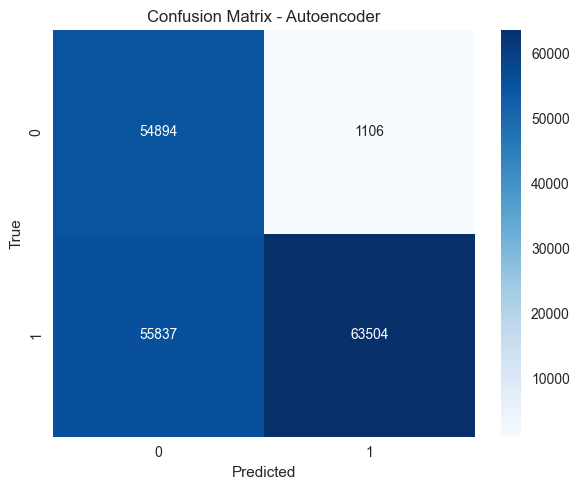

In [49]:
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Autoencoder")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

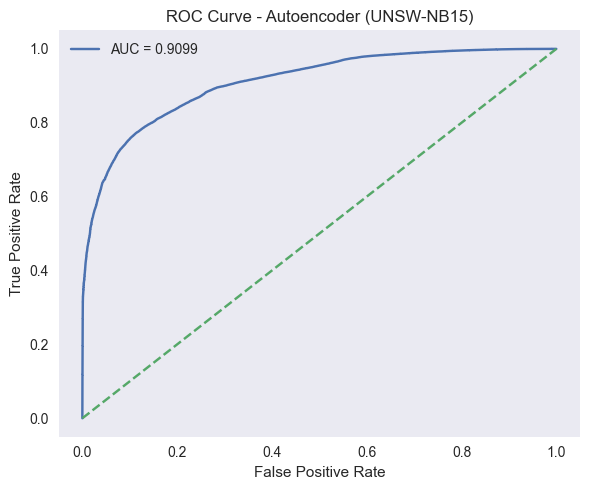

In [52]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, roc_thresholds = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Autoencoder (UNSW-NB15)")
plt.legend()
plt.grid()
plt.tight_layout()

